In [ ]:
import data_utils as da
import pandas as pd

icelandic = da.get_ice()
ephishgen = da.get_ephish()

real_data = da.get_known()
real_data = fromreal_data.sample(n=50000, random_state=42).reset_index(drop=True)

emails_df = pd.concat([ephishgen, real_data], ignore_index=True)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# Concat subject and body
X_text = emails_df['Subject'].fillna("") + " " + emails_df['Body'].fillna("")
y = emails_df['type']

# 2. Initialize and Fit a single TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10_000)
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print(f"Shape of TF-IDF matrix: {X_tfidf.shape}")

# 3. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of TF-IDF matrix: (61502, 10000)
Shape of X_train: (49201, 10000)
Shape of X_test: (12301, 10000)
Shape of y_train: (49201,)
Shape of y_test: (12301,)


# Logistic Regression

Logistic Regression Model Performance on Test Set:
Accuracy: 0.9674823185106902

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      6531
           1       0.97      0.96      0.97      5770

    accuracy                           0.97     12301
   macro avg       0.97      0.97      0.97     12301
weighted avg       0.97      0.97      0.97     12301



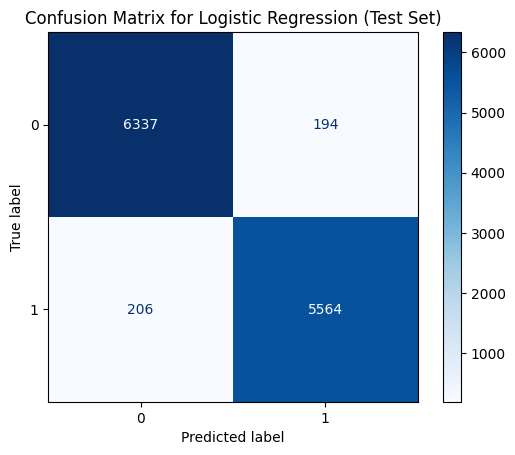

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model on the training data
log_history = log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = log_reg_model.predict(X_test)

# Evaluate the model on the test set
print("Logistic Regression Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=log_reg_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression (Test Set)')
plt.show()

In [6]:
import pandas as pd


feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the coefficients from the Logistic Regression model
# For binary classification, coef_ is usually a 1D array or 2D array with 1 row.
coefficients = log_reg_model.coef_[0]

# Create a DataFrame to store ture names and their coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to find the most influential words
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Influential Words (Positive Coefficients - indicating type 1/phishing):")
display(coef_df[coef_df['Coefficient'] > 0].head(20))

print("\nTop 10 Most Influential Words (Negative Coefficients - indicating type 0/normal):")
display(coef_df[coef_df['Coefficient'] < 0].head(20))

Top 10 Most Influential Words (Positive Coefficients - indicating type 1/phishing):


,Feature,Coefficient,Abs_Coefficient
5413,link,7.896908,7.896908
9974,your,5.900621,5.900621
9971,you,5.119117,5.119117
1147,attachment,4.615126,4.615126
3004,document,4.511145,4.511145
4641,immediate,4.219394,4.219394
2152,company,4.126282,4.126282
4928,invoice,3.921554,3.921554
203,2005,3.874384,3.874384
8538,statements,3.812620,3.812620



Top 10 Most Influential Words (Negative Coefficients - indicating type 0/normal):


,Feature,Coefficient,Abs_Coefficient
9918,wrote,-7.783413,7.783413
8978,thanks,-7.097906,7.097906
199,2001,-6.088693,6.088693
205,2007,-5.547581,5.547581
6421,org,-5.508717,5.508717
455,713,-5.088607,5.088607
3203,edu,-4.989385,4.989385
3357,enron,-4.859236,4.859236
8977,thank,-4.766567,4.766567
2621,date,-4.696320,4.696320


# Random Forest

Random Forest Classifier Model Performance on Test Set:
Accuracy: 0.9640679619543127

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      6531
           1       0.97      0.96      0.96      5770

    accuracy                           0.96     12301
   macro avg       0.96      0.96      0.96     12301
weighted avg       0.96      0.96      0.96     12301



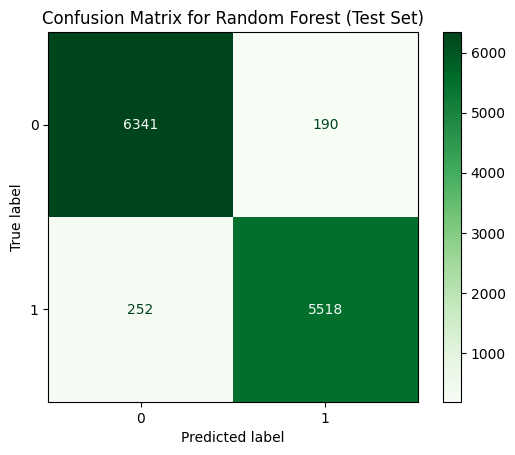

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier model
# Using a reasonable number of estimators; can be tuned later.
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test_rf = random_forest_model.predict(X_test)

# Evaluate the model on the test set
print("Random Forest Classifier Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_rf))

# Generate and display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_test_rf, labels=random_forest_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp_rf.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Random Forest (Test Set)')
plt.show()

# Naive Bayes

Naive Bayes Model Performance on Test Set:
Accuracy: 0.9424437037639216

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      6531
           1       0.96      0.92      0.94      5770

    accuracy                           0.94     12301
   macro avg       0.94      0.94      0.94     12301
weighted avg       0.94      0.94      0.94     12301



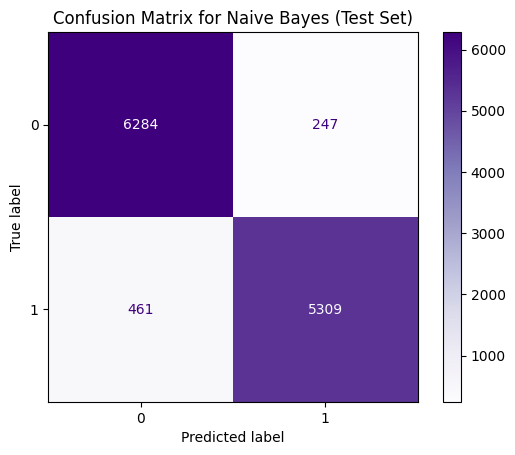

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Multinomial Naive Bayes model
# MultinomialNB is well-suited for classification with discrete features (like word counts or TF-IDF scores).
naive_bayes_model = MultinomialNB()

# Train the model on the training data
naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test_nb = naive_bayes_model.predict(X_test)

# Evaluate the model on the test set
print("Naive Bayes Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_nb))

# Generate and display the confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_test_nb, labels=naive_bayes_model.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=naive_bayes_model.classes_)
disp_nb.plot(cmap=plt.cm.Purples)
plt.title('Confusion Matrix for Naive Bayes (Test Set)')
plt.show()

# MLP

Multi Layer Perceptron Model Performance on Test Set:
Accuracy: 0.9723599707340866

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      6531
           1       0.97      0.97      0.97      5770

    accuracy                           0.97     12301
   macro avg       0.97      0.97      0.97     12301
weighted avg       0.97      0.97      0.97     12301



/hpchome/axels22/hf_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


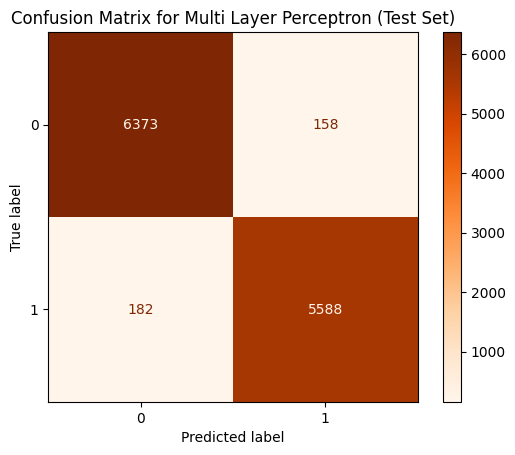

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Multi Layer Perceptron classifier
# Using default parameters for initial testing. These can be tuned later.
mlp_model = MLPClassifier(random_state=42, max_iter=200, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, verbose=False)

# Train the model on the training data
mlp_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test_mlp = mlp_model.predict(X_test)

# Evaluate the model on the test set
print("Multi Layer Perceptron Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_test_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_mlp))

# Generate and display the confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_test_mlp, labels=mlp_model.classes_)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp_model.classes_)
disp_mlp.plot(cmap=plt.cm.Oranges)
plt.title('Confusion Matrix for Multi Layer Perceptron (Test Set)')
plt.show()

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import scipy.sparse as sp
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Convert sparse matrix to dense torch tensors
# Do it in chunks to avoid memory explosion
def sparse_to_tensor(X):
    if sp.issparse(X):
        X = X.toarray()
    return torch.FloatTensor(X)

X_train_t = sparse_to_tensor(X_train).to(device)
X_test_t = sparse_to_tensor(X_test).to(device)
y_train_t = torch.LongTensor(y_train.values).to(device)
y_test_t = torch.LongTensor(y_test.values).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512)

# Define MLP — matches sklearn default hidden layer sizes (100,)
# but we add more capacity given the large input
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model_mlp = MLP(input_dim=X_train.shape[1]).to(device)
print(model_mlp)

# Training setup
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model_mlp.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_mlp(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

# Evaluation
model_mlp.eval()
all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_mlp(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())

print("\nMLP (GPU) Performance:")
print("Accuracy:", accuracy_score(y_test, all_preds))
print("\nClassification Report:\n", classification_report(y_test, all_preds))

Using: cuda


/var/tmp/ipykernel_385904/4251093178.py:20: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  y_train_t = torch.LongTensor(y_train.values).to(device)


MLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=2, bias=True)
  )
)
Epoch 1/10 - Loss: 0.1831
Epoch 2/10 - Loss: 0.0435
Epoch 3/10 - Loss: 0.0213
Epoch 4/10 - Loss: 0.0107
Epoch 5/10 - Loss: 0.0050
Epoch 6/10 - Loss: 0.0027
Epoch 7/10 - Loss: 0.0017
Epoch 8/10 - Loss: 0.0017
Epoch 9/10 - Loss: 0.0013
Epoch 10/10 - Loss: 0.0010

MLP (GPU) Performance:
Accuracy: 0.9678074953255833

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      6531
           1       0.96      0.97      0.97      5770

    accuracy                           0.97     12301
   macro avg       0.97      0.97      0.97     12301
weighted avg       0.97      0.97      0.97     12301



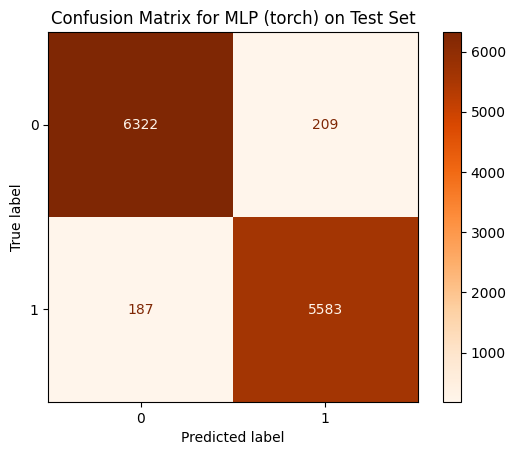

In [11]:
cm_mlp = confusion_matrix(y_test, all_preds)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=[0, 1])
disp_mlp.plot(cmap=plt.cm.Oranges)
plt.title('Confusion Matrix for MLP (torch) on Test Set')
plt.show()

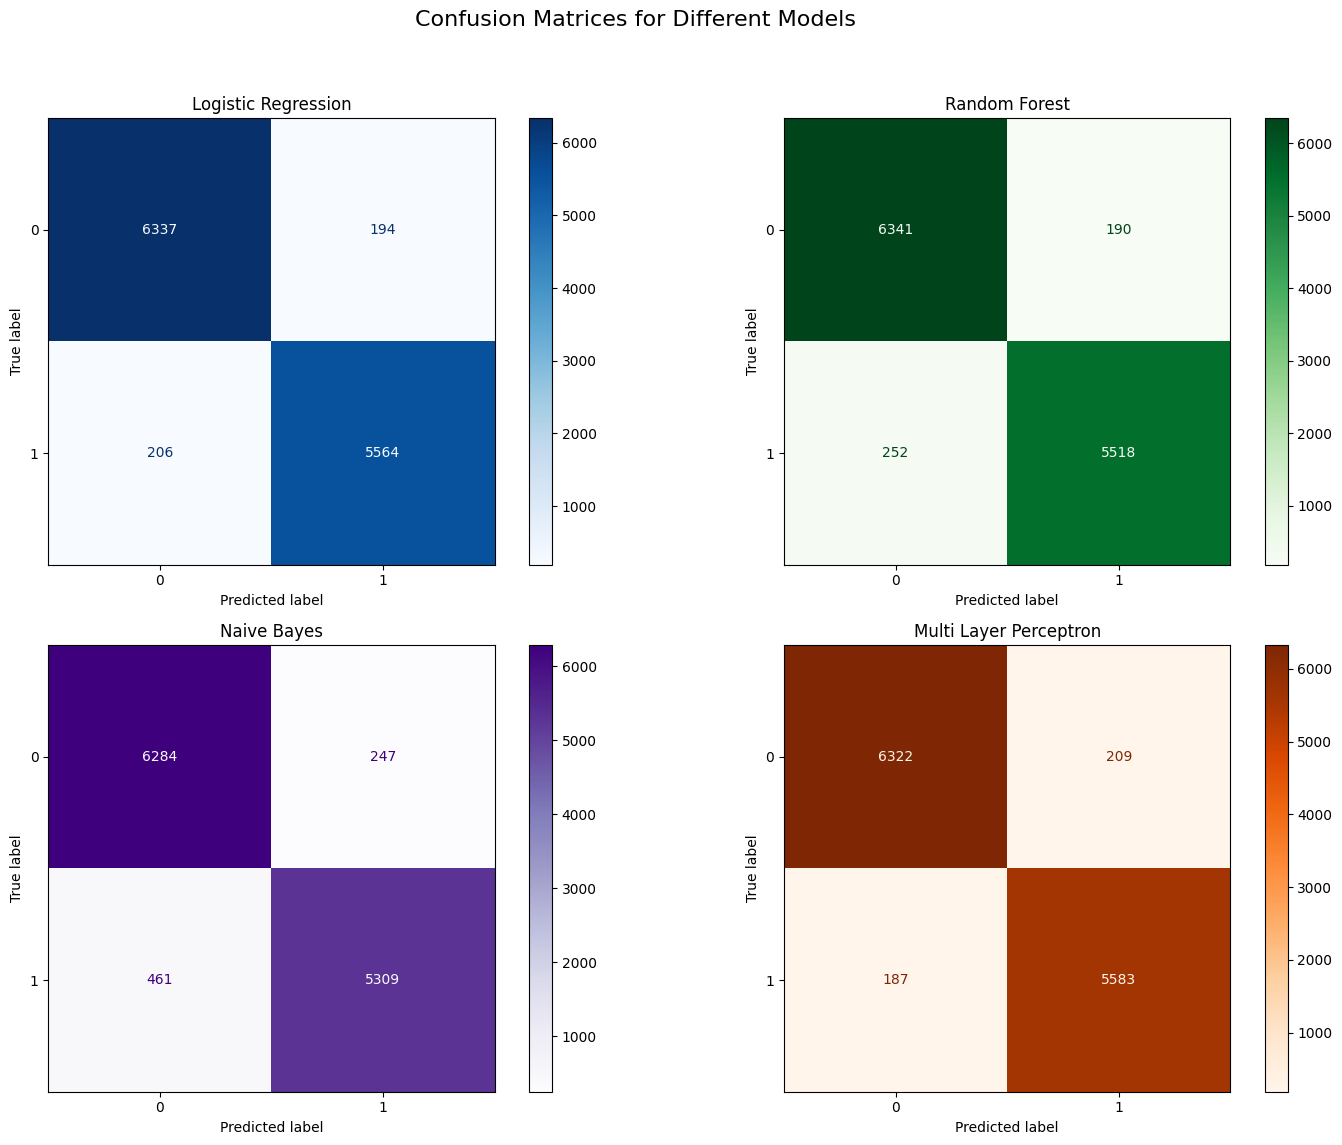

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Confusion Matrices for Different Models', fontsize=16)

# Plot Logistic Regression Confusion Matrix
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp_log_reg.plot(cmap=plt.cm.Blues, ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')

# Plot Random Forest Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp_rf.plot(cmap=plt.cm.Greens, ax=axes[0, 1])
axes[0, 1].set_title('Random Forest')

# Plot Naive Bayes Confusion Matrix
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=naive_bayes_model.classes_)
disp_nb.plot(cmap=plt.cm.Purples, ax=axes[1, 0])
axes[1, 0].set_title('Naive Bayes')

# Plot Multi Layer Perceptron Confusion Matrix
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=mlp_model.classes_)
disp_mlp.plot(cmap=plt.cm.Oranges, ax=axes[1, 1])
axes[1, 1].set_title('Multi Layer Perceptron')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# DistillBert

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [2]:
import data_utils as da
import pandas as pd

fromreal_data = da.get_known()
fromreal_data = fromreal_data.sample(n=50000, random_state=42).reset_index(drop=True)
ephishgen = da.get_ephish()
emails_df = pd.concat([ephishgen, fromreal_data], ignore_index=True)


Loaded Giri_EnronSpamSubset.csv: 9570 samples
Loaded Al-Subaiey_CEAS.csv: 38918 samples
Loaded Champa_Trec.csv: 122661 samples
Loaded Al-Subaiey_Ling.csv: 2797 samples
Loaded Al-Subaiey_Enron.csv: 29225 samples
Loaded Giri_LingSpam.csv: 2590 samples
Loaded Al-Subaiey_SpamAssassin.csv: 5784 samples
Count of emails by 'type':
type
0    114052
1     97493
Name: count, dtype: int64

Percentage breakdown:
Normal emails (type 0): 53.91%
Phishing emails (type 1): 46.09%

Loaded data succesfully (16616 emails) from data/ephish_emails.json
Count of emails by 'type':
type
1    5996
0    5506
Name: count, dtype: int64

Percentage breakdown:
Normal emails (type 0): 47.87%
Phishing emails (type 1): 52.13%



In [3]:
emails_df

,Subject,Body,type
0,Aligning Sales and Marketing Strategies,"Hi Grace,\n\nI hope you’re doing well! As we c...",0
1,Immediate Audit Action Required: Confidential ...,Subject: Immediate Audit Action Required: Conf...,1
2,Critical: Security Update Required for Your So...,"Dear Jay,\n\nAs a trusted partner, we prioriti...",1
3,Urgent: Immediate Vendor Payment Required,"Hello Angela,\n\nThis is James C., from the fi...",1
4,Request for Marketing Materials for the Upcomi...,"Hi Team,\n\nWe have an exciting promotional ev...",0
...,...,...,...
61497,,kExtandder is here now! Do not waise your time...,1
61498,,"re : transport flash for feb 00 heidi , yes le...",0
61499,,the watch you always wanted BUY YOUR OWN ROLEX...,1
61500,,"""Sunday Morning"" bringing the commute to your ...",0


In [6]:
emails_df['Text'] = emails_df['Subject'].fillna('') + ' ' + emails_df['Body'].fillna('')

from datasets import Dataset

dataset = Dataset.from_pandas(emails_df[['Text', 'type']])

def tokenize(batch):
    return tokenizer(batch['Text'], truncation=True, max_length=512)

dataset = dataset.map(tokenize, batched=True, num_proc=16)
emails_df['tokenized_body'] = dataset['input_ids']

Map (num_proc=16):   0%|          | 0/61502 [00:00<?, ? examples/s]

Training dataset size: 49201
Evaluation dataset size: 12301


[RANK 0] Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.



Starting fine-tuning...


/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Step,Training Loss
500,0.244004
1000,0.176629
1500,0.126819
2000,0.105799
2500,0.111151
3000,0.099020
3500,0.090016
4000,0.069570
4500,0.075459
5000,0.071534


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saving the dataset (0/1 shards):   0%|          | 0/49201 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/12301 [00:00<?, ? examples/s]

Model and datasets saved!


/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


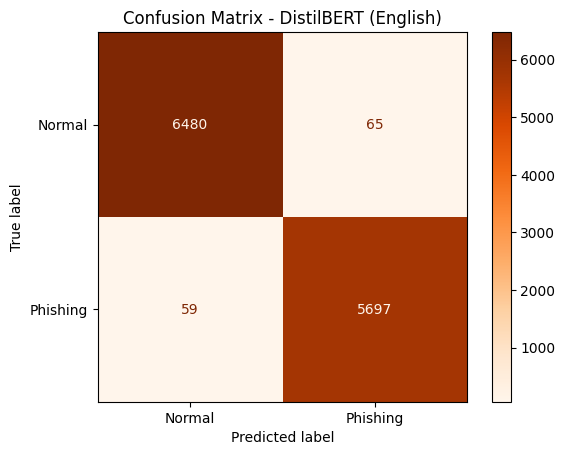


Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      6545
    Phishing       0.99      0.99      0.99      5756

    accuracy                           0.99     12301
   macro avg       0.99      0.99      0.99     12301
weighted avg       0.99      0.99      0.99     12301



In [7]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Convert tokenized_body lists to dictionary format expected by Dataset, including labels
def prepare_data_for_dataset(df):
    return [{'input_ids': tokens, 'labels': label} for tokens, label in zip(df['tokenized_body'], df['type'])]

# Create Hugging Face Dataset objects
icelandic_dataset_dict = Dataset.from_list(prepare_data_for_dataset(emails_df))

# Split the dataset into training and validation sets
train_test_split_ratio = 0.8
split_result = icelandic_dataset_dict.train_test_split(test_size=1-train_test_split_ratio, seed=42)
train_dataset = split_result['train']
eval_dataset = split_result['test']
print(f"Training dataset size: {len(train_dataset)}")
print(f"Evaluation dataset size: {len(eval_dataset)}")

# Initialize data collator
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    max_length=tokenizer.model_max_length,
    return_tensors="pt"
)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./distilbert_finetuned_classifier",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=500,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

# Train
print("\nStarting fine-tuning...")
trainer.train()
print("Fine-tuning complete!")

# Save model, tokenizer and datasets
trainer.save_model("./distilbert_finetuned_classifier")
tokenizer.save_pretrained("./distilbert_finetuned_classifier")
train_dataset.save_to_disk("./distilbert_finetuned_classifier/train_dataset")
eval_dataset.save_to_disk("./distilbert_finetuned_classifier/eval_dataset")
print("Model and datasets saved!")

# Get predictions for confusion matrix
predictions = trainer.predict(eval_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = eval_dataset['labels']

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Phishing'])
disp.plot(cmap=plt.cm.Oranges)
plt.title('Confusion Matrix - DistilBERT (English)')
plt.show()

# Print metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=['Normal', 'Phishing']))